# Accelerator jobs and runtime lifecycle

CPU companion; no accelerator is required. TPU execution not validated.

- Launch and reap a real bounded subprocess with explicit runtime requirements.
- Distinguish successful completion, worker failure and supervisor timeout.
- Keep configuration and observed runtime evidence with the run artifact.

A training command starts, but that does not tell us whether its runtime is correct, its initialization finished, or its process will ever exit. We will supervise a real small JAX worker through success, rejected runtime requirements and an intentionally stalled update. The result will contain observed process outcomes rather than a list of assumed job statuses.

## The idea

Workload lifecycle states describe what a job can do now. Creation, startup, readiness, execution, completion and failure are different transitions. Observing the process alone does not establish that its useful work is available.

## A running process is not necessarily a ready service

A process can exist while loading weights, waiting for resources or failing repeated health checks. A ready state should correspond to a concrete capability, such as accepting a validated inference request, rather than elapsed startup time.

Attach each transition to an observed event and define timeouts. If a job is rejected before launch, do not record that as a completed training run. If it terminates, preserve whether useful work completed or a failure interrupted it.

The lifetime bars compare actual process intervals in this fixture. They do not by themselves show readiness or accelerator utilization. Use the state timeline to explain what each interval includes.

### Pause and reason

Why separate startup duration from useful execution duration?

<details><summary>Compare your reasoning</summary>

They have different causes and operational effects. Provisioning or loading changes may improve startup without changing the numerical workload's speed.

</details>

## Separate intent from observation

The configuration requests CPU and at least one device. The started event records what JAX actually discovered. Requesting $999$ devices should fail before training rather than silently run on fewer resources. An exit code of zero alone is insufficient: a worker that exits early without its completed event did not satisfy our job contract. Conversely, the last progress event is not proof of completion.

## The process handle is the lifecycle authority

The supervisor owns a Popen handle and calls communicate with a deadline. On timeout it requests termination, waits briefly, then kills and reaps if needed. Merely writing timed_out into a JSON file would leave the actual worker alive. Exit values differ by platform: on POSIX a signal can appear as a negative return code, so our checks require a nonzero outcome rather than one portable magic number. This worker does not spawn descendants; a production process tree needs its own process-group or scheduler cancellation contract.

## Ready means initialization finished

The worker imports JAX, validates the device contract, constructs data and compiles one update using a disposable result. It waits for that warmup result before emitting ready. The real parameters, momentum and random key remain unchanged during warmup. This makes the first progress event a genuine update from initial state, and keeps compile time separate from steady update time. A started process can still fail before ready.

## Configuration should reject nonsense early

Total steps, batch size, checkpoint cadence and minimum device count must be positive integers. The minibatch cannot exceed the $64$-example fixture when sampling without replacement. Momentum lies in $[0,1)$, and learning rate is positive under this example’s bounded configuration. These validation choices document the teaching workload, not all valid optimizers. The worker command is an argument list and does not invoke a shell.

## Treat a deadline as evidence, not a diagnosis

The lab inserts a real sleep after initialization and emits stall_injected. The supervisor times out and terminates the child. In an actual job, reaching a deadline would not by itself distinguish slow compilation, input starvation, deadlock or a workload that simply needs more time. Keep the last event, stderr and runtime contract before choosing a repair. Our intentional event makes this particular test diagnosable without pretending to emulate every failure.

## Transfer the contract to available hardware

On a separately prepared accelerator host, the same launch function accepts backend gpu or tpu and a required device count. It requests that backend through JAX_PLATFORMS and records discovery; missing runtime support fails. Do not run that path on a laptop and call failure a hardware benchmark. Multi-host initialization, scheduler allocation, credentials, preemption signals and target-specific installation remain additional deployment contracts. No cloud resource is provisioned by this lesson.

## Create the local artifact helpers

Create main.py with this block. Run python3 main.py in the CPU course environment.

In [1]:
"""Bounded local JAX workload operations. No scheduler, cloud, or GPU emulator."""
from pathlib import Path
import hashlib
import json
import math
import os
import subprocess
import sys
import tempfile
import time


def digest(value):
    return hashlib.sha256(json.dumps(value, sort_keys=True, separators=(',', ':'), allow_nan=False).encode()).hexdigest()


def atomic_json(path, value):
    """Replace one local JSON file only after its bytes have been flushed."""
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    fd, temporary = tempfile.mkstemp(prefix=path.name+'.', suffix='.tmp', dir=path.parent)
    try:
        with os.fdopen(fd, 'w') as stream:
            json.dump(value, stream, sort_keys=True, allow_nan=False)
            stream.flush(); os.fsync(stream.fileno())
        os.replace(temporary, path)
    finally:
        if os.path.exists(temporary): os.unlink(temporary)

The only filesystem writes are to the caller-selected run directory. Stable JSON encoding makes hashes reproducible.

## Define the supervised worker

Append this block to main.py. Run python3 main.py in the CPU course environment.

In [2]:
# This file is materialized only inside the caller-owned temporary run folder.
WORKER = r'''
import hashlib, json, os, sys, time
from pathlib import Path
import jax
import jax.numpy as jnp
import numpy as np
root = Path(sys.argv[1])
cfg = json.loads((root/'config.json').read_text())
worker_hash = hashlib.sha256(Path(__file__).read_bytes()).hexdigest()
def emit(event, **fields):
    print(json.dumps(dict(event=event, monotonic_s=time.monotonic(), **fields)), flush=True)
def digest(value):
    return hashlib.sha256(json.dumps(value,sort_keys=True,separators=(',', ':'),allow_nan=False).encode()).hexdigest()
def write_checkpoint(state):
    target = root/'checkpoint.json'; temporary = root/'checkpoint.pending'
    with temporary.open('w') as stream:
        json.dump(dict(state,checksum=digest(state)),stream,sort_keys=True,allow_nan=False)
        stream.flush(); os.fsync(stream.fileno())
    os.replace(temporary,target)
    emit('checkpoint',step=state['step'],state_hash=digest(state))
try:
    emit('started',pid=os.getpid(),backend=jax.default_backend(),device_count=jax.device_count())
    if jax.default_backend() != cfg['backend'] or jax.device_count() < cfg['min_devices']:
        raise ValueError('runtime backend/device contract failed')
    x = jnp.linspace(-1.,1.,64); y = 2*x+1
    data_hash = digest(dict(x=np.asarray(x).tolist(),y=np.asarray(y).tolist()))
    training = {name:cfg[name] for name in ('seed','learning_rate','momentum','batch_size')}
    config_hash = digest(training)
    if cfg['resume']:
        saved = json.loads((root/'checkpoint.json').read_text())
        checksum = saved.pop('checksum',None)
        if checksum != digest(saved) or saved.get('worker_hash') != worker_hash:
            raise ValueError('checkpoint checksum/source mismatch')
        if saved['schema_version'] != 1 or saved['config_hash'] != config_hash or saved['data_hash'] != data_hash:
            raise ValueError('checkpoint provenance mismatch')
        state = saved
        step = saved['step']; params=jnp.array(saved['params']); velocity=jnp.array(saved['velocity']); key=jnp.array(saved['key'],dtype=jnp.uint32)
        if not isinstance(step,int) or isinstance(step,bool) or step < 0 or step > cfg['steps'] or params.shape != (2,) or velocity.shape != (2,) or key.shape != (2,):
            raise ValueError('invalid checkpoint state shape or step')
        if not bool(jnp.all(jnp.isfinite(params))) or not bool(jnp.all(jnp.isfinite(velocity))):
            raise ValueError('nonfinite checkpoint state')
        emit('restored',step=step,state_hash=digest(saved))
    else:
        step=0; params=jnp.zeros(2);velocity=jnp.zeros(2);key=jax.random.PRNGKey(cfg['seed'])
    def update(params,velocity,key):
        key, sample = jax.random.split(key)
        indices=jax.random.choice(sample,64,(cfg['batch_size'],),replace=False)
        objective=lambda p:jnp.mean((p[0]*x[indices]+p[1]-y[indices])**2)
        loss, grad=jax.value_and_grad(objective)(params)
        velocity=cfg['momentum']*velocity+grad
        params=params-cfg['learning_rate']*velocity
        return params,velocity,key,loss
    compiled=jax.jit(update)
    # Compile and synchronize once without consuming actual training state.
    begin=time.perf_counter();warm=compiled(params,velocity,key);jax.block_until_ready(warm)
    emit('ready',compile_warmup_s=time.perf_counter()-begin,step=step)
    while step < cfg['steps']:
        if cfg.get('stall_at') == step:
            emit('stall_injected',step=step)
            time.sleep(cfg.get('stall_seconds',10.))
        begin=time.perf_counter()
        params,velocity,key,loss=compiled(params,velocity,key);jax.block_until_ready((params,velocity,key,loss))
        elapsed=time.perf_counter()-begin;step+=1
        state=dict(schema_version=1,worker_hash=worker_hash,step=step,params=np.asarray(params).tolist(),velocity=np.asarray(velocity).tolist(),key=np.asarray(key).tolist(),config_hash=config_hash,data_hash=data_hash)
        emit('progress',step=step,loss=float(loss),examples=cfg['batch_size'],update_s=elapsed,state_hash=digest(state))
        if step % cfg['checkpoint_every'] == 0 or step == cfg['steps']:
            write_checkpoint(state)
        if cfg.get('fail_after') == step:
            raise RuntimeError('controlled failure after update')
    write_checkpoint(state)
    emit('completed',step=step,state_hash=digest(state))
except Exception as error:
    emit('failed',kind=type(error).__name__,message=str(error))
    raise SystemExit(23)
'''

The string is a real Python program launched in a separate process. It emits structured events, synchronizes JAX updates and preserves complete state.

## Add bounded launch and result collection

Append this block to main.py. Run python3 main.py in the CPU course environment.

In [3]:
def default_config(**changes):
    cfg=dict(seed=3,learning_rate=.04,momentum=.8,batch_size=8,steps=8,
             checkpoint_every=2,backend='cpu',min_devices=1,resume=False,
             fail_after=None,stall_at=None,stall_seconds=10.)
    cfg.update(changes)
    for name in ('steps','checkpoint_every','batch_size','min_devices'):
        if not isinstance(cfg[name],int) or isinstance(cfg[name],bool) or cfg[name] < 1: raise ValueError(name+' must be a positive integer')
    if cfg['batch_size'] > 64 or not 0 <= cfg['momentum'] < 1 or not 0 < cfg['learning_rate'] < 1:
        raise ValueError('invalid training configuration')
    return cfg


def launch(root, config=None, timeout=10.):
    root=Path(root);root.mkdir(parents=True,exist_ok=True)
    cfg=default_config(**(config or {}))
    if timeout <= 0: raise ValueError('timeout must be positive')
    atomic_json(root/'config.json',cfg)
    worker=root/'worker.py';worker.write_text(WORKER)
    env=dict(os.environ,JAX_PLATFORMS=cfg['backend'],PYTHONUNBUFFERED='1')
    started=time.perf_counter()
    process=subprocess.Popen([sys.executable,str(worker),str(root)],stdout=subprocess.PIPE,stderr=subprocess.PIPE,text=True,env=env)
    timed_out=False
    try:
        stdout,stderr=process.communicate(timeout=timeout)
    except subprocess.TimeoutExpired:
        timed_out=True;process.terminate()
        try: stdout,stderr=process.communicate(timeout=1.)
        except subprocess.TimeoutExpired:
            process.kill();stdout,stderr=process.communicate(timeout=1.)
    wall=time.perf_counter()-started
    events=[]; malformed=[]
    for line in stdout.splitlines():
        if not line.strip(): continue
        try:
            event=json.loads(line)
            if not isinstance(event,dict) or 'event' not in event: raise ValueError('not an event')
            events.append(event)
        except (ValueError,TypeError): malformed.append(line)
    status='timed_out' if timed_out else 'completed' if process.returncode == 0 and not malformed and events and events[-1]['event']=='completed' else 'failed'
    result=dict(status=status,returncode=process.returncode,wall_s=wall,events=events,stderr=stderr,
                worker_hash=hashlib.sha256(WORKER.encode()).hexdigest(),config=cfg,malformed_stdout=malformed)
    atomic_json(root/'run.json',result)
    return result

The supervisor owns the child handle, captures its output and always waits for termination after a timeout.

## Exercise all three lifecycle outcomes

Append this block to main.py. Run python3 main.py in the CPU course environment.

In [4]:
with tempfile.TemporaryDirectory(prefix='ops-lifecycle-') as folder:
    base = Path(folder)
    successful = launch(base/'success')
    rejected = launch(base/'wrong-runtime',dict(min_devices=999))
    stalled = launch(base/'timeout',dict(stall_at=0,stall_seconds=20),timeout=6)
assert successful['status'] == 'completed'
assert rejected['status'] == 'failed' and rejected['returncode'] != 0
assert stalled['status'] == 'timed_out' and stalled['returncode'] != 0
assert any(e['event']=='stall_injected' for e in stalled['events'])
print('statuses:',successful['status'],rejected['status'],stalled['status'])
print('actual exit codes:',successful['returncode'],rejected['returncode'],stalled['returncode'])

statuses: completed failed timed_out
actual exit codes: 0 23 -15


Each outcome comes from a real subprocess. Temporary directories contain and clean up every artifact.

## Run the example

In [5]:
"""Bounded local JAX workload operations. No scheduler, cloud, or GPU emulator."""
from pathlib import Path
import hashlib
import json
import math
import os
import subprocess
import sys
import tempfile
import time


def digest(value):
    return hashlib.sha256(json.dumps(value, sort_keys=True, separators=(',', ':'), allow_nan=False).encode()).hexdigest()


def atomic_json(path, value):
    """Replace one local JSON file only after its bytes have been flushed."""
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    fd, temporary = tempfile.mkstemp(prefix=path.name+'.', suffix='.tmp', dir=path.parent)
    try:
        with os.fdopen(fd, 'w') as stream:
            json.dump(value, stream, sort_keys=True, allow_nan=False)
            stream.flush(); os.fsync(stream.fileno())
        os.replace(temporary, path)
    finally:
        if os.path.exists(temporary): os.unlink(temporary)

# This file is materialized only inside the caller-owned temporary run folder.
WORKER = r'''
import hashlib, json, os, sys, time
from pathlib import Path
import jax
import jax.numpy as jnp
import numpy as np
root = Path(sys.argv[1])
cfg = json.loads((root/'config.json').read_text())
worker_hash = hashlib.sha256(Path(__file__).read_bytes()).hexdigest()
def emit(event, **fields):
    print(json.dumps(dict(event=event, monotonic_s=time.monotonic(), **fields)), flush=True)
def digest(value):
    return hashlib.sha256(json.dumps(value,sort_keys=True,separators=(',', ':'),allow_nan=False).encode()).hexdigest()
def write_checkpoint(state):
    target = root/'checkpoint.json'; temporary = root/'checkpoint.pending'
    with temporary.open('w') as stream:
        json.dump(dict(state,checksum=digest(state)),stream,sort_keys=True,allow_nan=False)
        stream.flush(); os.fsync(stream.fileno())
    os.replace(temporary,target)
    emit('checkpoint',step=state['step'],state_hash=digest(state))
try:
    emit('started',pid=os.getpid(),backend=jax.default_backend(),device_count=jax.device_count())
    if jax.default_backend() != cfg['backend'] or jax.device_count() < cfg['min_devices']:
        raise ValueError('runtime backend/device contract failed')
    x = jnp.linspace(-1.,1.,64); y = 2*x+1
    data_hash = digest(dict(x=np.asarray(x).tolist(),y=np.asarray(y).tolist()))
    training = {name:cfg[name] for name in ('seed','learning_rate','momentum','batch_size')}
    config_hash = digest(training)
    if cfg['resume']:
        saved = json.loads((root/'checkpoint.json').read_text())
        checksum = saved.pop('checksum',None)
        if checksum != digest(saved) or saved.get('worker_hash') != worker_hash:
            raise ValueError('checkpoint checksum/source mismatch')
        if saved['schema_version'] != 1 or saved['config_hash'] != config_hash or saved['data_hash'] != data_hash:
            raise ValueError('checkpoint provenance mismatch')
        state = saved
        step = saved['step']; params=jnp.array(saved['params']); velocity=jnp.array(saved['velocity']); key=jnp.array(saved['key'],dtype=jnp.uint32)
        if not isinstance(step,int) or isinstance(step,bool) or step < 0 or step > cfg['steps'] or params.shape != (2,) or velocity.shape != (2,) or key.shape != (2,):
            raise ValueError('invalid checkpoint state shape or step')
        if not bool(jnp.all(jnp.isfinite(params))) or not bool(jnp.all(jnp.isfinite(velocity))):
            raise ValueError('nonfinite checkpoint state')
        emit('restored',step=step,state_hash=digest(saved))
    else:
        step=0; params=jnp.zeros(2);velocity=jnp.zeros(2);key=jax.random.PRNGKey(cfg['seed'])
    def update(params,velocity,key):
        key, sample = jax.random.split(key)
        indices=jax.random.choice(sample,64,(cfg['batch_size'],),replace=False)
        objective=lambda p:jnp.mean((p[0]*x[indices]+p[1]-y[indices])**2)
        loss, grad=jax.value_and_grad(objective)(params)
        velocity=cfg['momentum']*velocity+grad
        params=params-cfg['learning_rate']*velocity
        return params,velocity,key,loss
    compiled=jax.jit(update)
    # Compile and synchronize once without consuming actual training state.
    begin=time.perf_counter();warm=compiled(params,velocity,key);jax.block_until_ready(warm)
    emit('ready',compile_warmup_s=time.perf_counter()-begin,step=step)
    while step < cfg['steps']:
        if cfg.get('stall_at') == step:
            emit('stall_injected',step=step)
            time.sleep(cfg.get('stall_seconds',10.))
        begin=time.perf_counter()
        params,velocity,key,loss=compiled(params,velocity,key);jax.block_until_ready((params,velocity,key,loss))
        elapsed=time.perf_counter()-begin;step+=1
        state=dict(schema_version=1,worker_hash=worker_hash,step=step,params=np.asarray(params).tolist(),velocity=np.asarray(velocity).tolist(),key=np.asarray(key).tolist(),config_hash=config_hash,data_hash=data_hash)
        emit('progress',step=step,loss=float(loss),examples=cfg['batch_size'],update_s=elapsed,state_hash=digest(state))
        if step % cfg['checkpoint_every'] == 0 or step == cfg['steps']:
            write_checkpoint(state)
        if cfg.get('fail_after') == step:
            raise RuntimeError('controlled failure after update')
    write_checkpoint(state)
    emit('completed',step=step,state_hash=digest(state))
except Exception as error:
    emit('failed',kind=type(error).__name__,message=str(error))
    raise SystemExit(23)
'''

def default_config(**changes):
    cfg=dict(seed=3,learning_rate=.04,momentum=.8,batch_size=8,steps=8,
             checkpoint_every=2,backend='cpu',min_devices=1,resume=False,
             fail_after=None,stall_at=None,stall_seconds=10.)
    cfg.update(changes)
    for name in ('steps','checkpoint_every','batch_size','min_devices'):
        if not isinstance(cfg[name],int) or isinstance(cfg[name],bool) or cfg[name] < 1: raise ValueError(name+' must be a positive integer')
    if cfg['batch_size'] > 64 or not 0 <= cfg['momentum'] < 1 or not 0 < cfg['learning_rate'] < 1:
        raise ValueError('invalid training configuration')
    return cfg


def launch(root, config=None, timeout=10.):
    root=Path(root);root.mkdir(parents=True,exist_ok=True)
    cfg=default_config(**(config or {}))
    if timeout <= 0: raise ValueError('timeout must be positive')
    atomic_json(root/'config.json',cfg)
    worker=root/'worker.py';worker.write_text(WORKER)
    env=dict(os.environ,JAX_PLATFORMS=cfg['backend'],PYTHONUNBUFFERED='1')
    started=time.perf_counter()
    process=subprocess.Popen([sys.executable,str(worker),str(root)],stdout=subprocess.PIPE,stderr=subprocess.PIPE,text=True,env=env)
    timed_out=False
    try:
        stdout,stderr=process.communicate(timeout=timeout)
    except subprocess.TimeoutExpired:
        timed_out=True;process.terminate()
        try: stdout,stderr=process.communicate(timeout=1.)
        except subprocess.TimeoutExpired:
            process.kill();stdout,stderr=process.communicate(timeout=1.)
    wall=time.perf_counter()-started
    events=[]; malformed=[]
    for line in stdout.splitlines():
        if not line.strip(): continue
        try:
            event=json.loads(line)
            if not isinstance(event,dict) or 'event' not in event: raise ValueError('not an event')
            events.append(event)
        except (ValueError,TypeError): malformed.append(line)
    status='timed_out' if timed_out else 'completed' if process.returncode == 0 and not malformed and events and events[-1]['event']=='completed' else 'failed'
    result=dict(status=status,returncode=process.returncode,wall_s=wall,events=events,stderr=stderr,
                worker_hash=hashlib.sha256(WORKER.encode()).hexdigest(),config=cfg,malformed_stdout=malformed)
    atomic_json(root/'run.json',result)
    return result

with tempfile.TemporaryDirectory(prefix='ops-lifecycle-') as folder:
    base = Path(folder)
    successful = launch(base/'success')
    rejected = launch(base/'wrong-runtime',dict(min_devices=999))
    stalled = launch(base/'timeout',dict(stall_at=0,stall_seconds=20),timeout=6)
assert successful['status'] == 'completed'
assert rejected['status'] == 'failed' and rejected['returncode'] != 0
assert stalled['status'] == 'timed_out' and stalled['returncode'] != 0
assert any(e['event']=='stall_injected' for e in stalled['events'])
print('statuses:',successful['status'],rejected['status'],stalled['status'])
print('actual exit codes:',successful['returncode'],rejected['returncode'],stalled['returncode'])

statuses: completed failed timed_out
actual exit codes: 0 23 -15


Expected: The actual child outcomes are completed, failed and timed_out. A worker requirement failure exits nonzero; the stalled worker is terminated and reaped.

## Three actual process lifetimes

Predict: Will the runtime-rejected job spend time training?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [6]:
visual_data={'kind':'bar','labels':['completed','runtime rejected','timed out'],'xlabel':'observed outcome','ylabel':'supervisor wall time (seconds)','series':[{'label':'actual local process','y':[successful['wall_s'],rejected['wall_s'],stalled['wall_s']]}]}

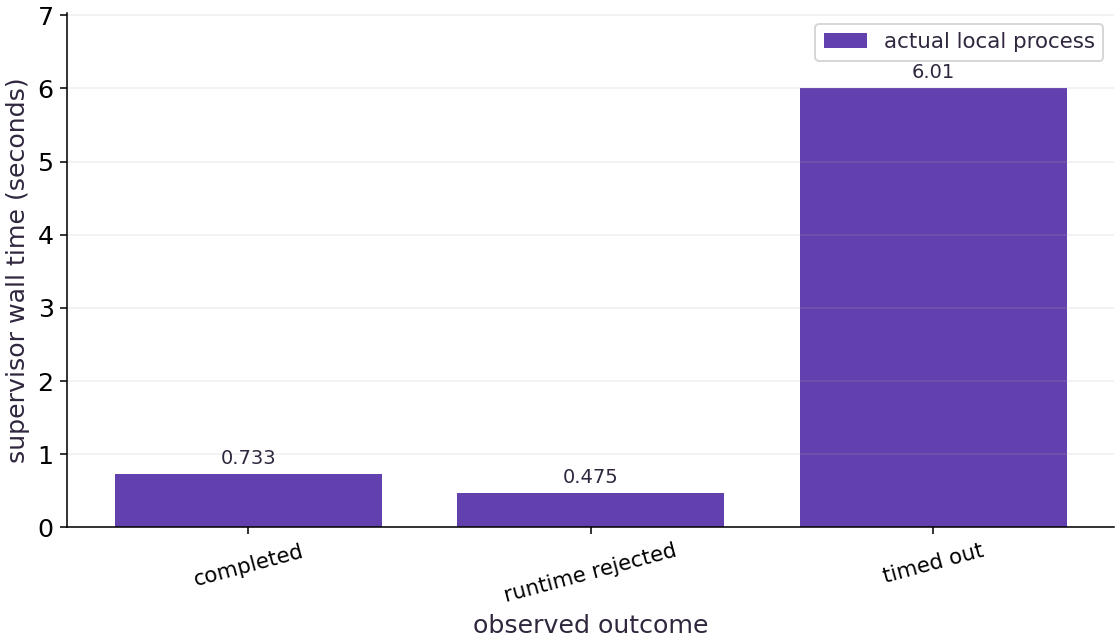

In [7]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal categories identify three actual child runs. The vertical axis is supervisor wall-clock seconds, from launch to reaped exit. The timeout bar reflects the configured deadline plus cancellation overhead. The failure bar includes Python and JAX startup before the runtime check rejects the job. These are measured durations, so their exact values vary across hosts and reruns.

### Connect it to the computation

Compare the bars with the event traces, not by height alone. The completed run contains progress and a completed event; the rejected run has no progress; the stalled run reaches ready but never finishes. A shorter failing bar does not mean an efficient job. This plot demonstrates lifecycle measurement on the local CPU, not accelerator throughput.

## A child that fails before training

Predict: Can an impossible device requirement produce valid training progress?

In [8]:
assert any(e['event']=='failed' and 'runtime' in e['message'] for e in rejected['events'])
assert not any(e['event']=='progress' for e in rejected['events'])

Expected: The runtime mismatch is recorded, and no update event exists.

This check links the failure classification to a concrete boundary in the worker lifecycle.

## A started process need not be ready

Predict: Which events occur before the injected stall?

In [9]:
names=[e['event'] for e in stalled['events']]
assert names.index('started') < names.index('ready') < names.index('stall_injected')
assert 'completed' not in names
print('timed-out worker events:',names)

timed-out worker events: ['started', 'ready', 'stall_injected']


Expected: The worker reaches ready, then stalls before its first update.

The sequence rules out startup failure in this controlled drill. A different trace would demand a different diagnosis.

## Your exercise

Launch a changed job with $3$ updates and batch size $5$. Verify the observed progress steps and completion event rather than relying only on its exit code.

In [10]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [11]:
with tempfile.TemporaryDirectory() as folder:
    short=launch(folder,dict(steps=3,batch_size=5))
assert short['status']=='completed'
assert [e['step'] for e in short['events'] if e['event']=='progress']==[1,2,3]
assert short['events'][-1]['step']==3

## Reject invalid work before spawning · Transfer / diagnosis

Try a zero step budget and an oversized minibatch. Require a clear configuration error for each.

Hint: Call default_config directly; no child should be needed.

In [12]:
# Write your attempt here.

## Reference reasoning

Validation makes an impossible workload fail at the caller boundary instead of consuming runtime first.

In [13]:
for values in [dict(steps=0),dict(batch_size=65)]:
    try: default_config(**values)
    except ValueError: pass
    else: raise AssertionError('invalid work accepted')

## Preserve a successful checkpoint · Transfer / diagnosis

Run $4$ updates in a temporary directory and verify that the final checkpoint and run record both refer to the completed work.

Hint: Read the files before leaving the temporary-directory context.

In [14]:
# Write your attempt here.

## Reference reasoning

A status and a durable artifact should agree about what was completed; neither should be assumed from the command alone.

In [15]:
with tempfile.TemporaryDirectory() as folder:
    result=launch(folder,dict(steps=4))
    saved=json.loads((Path(folder)/'checkpoint.json').read_text())
    record=json.loads((Path(folder)/'run.json').read_text())
    assert saved['step']==4 and record['status']=='completed'
    assert record['worker_hash']==saved['worker_hash']

## Checkpoint

What must a timeout handler do beyond recording a timeout status?

1. Leave the child running so it might finish later
2. Terminate or kill as required, then wait for the actual child to exit
3. Delete the last log line

## Diagnose

Use the last structured event to locate the boundary: no ready event points toward runtime or initialization; ready without progress points toward update/input work; completed with a nonzero exit still requires investigation. Preserve stderr. Verify the child has exited before retrying so two runs do not write the same checkpoint.

## Evidence

Keep actual child exit codes, bounded timeout/termination output and proof that children were reaped. Distinguish launch failure, failed preflight, slow work and a stalled job.

## Carry forward

- A requested runtime and an observed runtime are separate facts.
- A process deadline needs cancellation and reaping, not just a status string.

## Primary references

- [Python subprocess management](https://docs.python.org/3/library/subprocess.html)
- [Python os.replace and fsync](https://docs.python.org/3/library/os.html#os.replace)
- [JAX asynchronous dispatch and synchronization](https://docs.jax.dev/en/latest/async_dispatch.html)
- [JAX device discovery](https://docs.jax.dev/en/latest/_autosummary/jax.devices.html)